In [1]:
# 1. 必要ライブラリのインポート
import os
import torch                                      # PyTorch（パイトーチ）
import matplotlib.pyplot as plt                  # matplotlib（マットプロットリブ）
import torchvision                               
from torchvision import transforms                
from torchvision.datasets import CIFAR10          # CIFAR-10（シファーイチゼロ）
from torch.utils.data import DataLoader          # DataLoader（データローダー）

# 2. ダウンロード先フォルダの指定
root_dir = './data/CIFAR10'

# 3. 画像変換の定義
transform = transforms.Compose([
    transforms.ToTensor(),                       # 画像をTensor（テンソル）に変換
    transforms.Normalize(
        (0.5, 0.5, 0.5),                         # 平均
        (0.5, 0.5, 0.5)                          # 標準偏差
    )
])

# 4. データセットのダウンロード
train_dataset = CIFAR10(
    root=root_dir,                               
    train=True,                                  
    download=True,                               
    transform=transform                          
)
test_dataset = CIFAR10(
    root=root_dir,
    train=False,
    download=True,
    transform=transform
)

# 5. DataLoaderの準備
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=8, shuffle=False)

# 6. フォルダ構造の確認
print('データ格納フォルダ →', os.listdir(root_dir))
print('内部ディレクトリ →', os.listdir(os.path.join(root_dir, 'cifar-10-batches-py')))


100%|██████████| 170M/170M [00:35<00:00, 4.82MB/s] 


Extracting ./data/CIFAR10\cifar-10-python.tar.gz to ./data/CIFAR10
Files already downloaded and verified
データ格納フォルダ → ['cifar-10-batches-py', 'cifar-10-python.tar.gz']
内部ディレクトリ → ['batches.meta', 'data_batch_1', 'data_batch_2', 'data_batch_3', 'data_batch_4', 'data_batch_5', 'readme.html', 'test_batch']


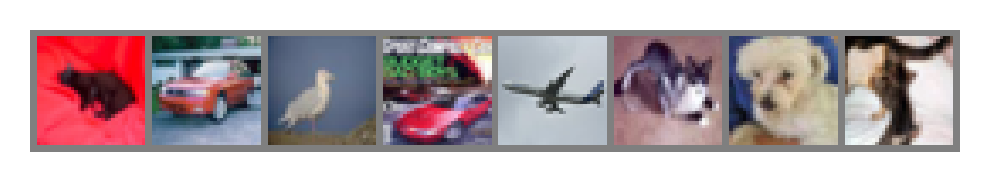

ラベル → [3, 1, 2, 1, 0, 3, 5, 3]


In [14]:
# 7. Notebook上でサンプル画像を表示する関数定義
import numpy as np

def imshow(img):
    img = img / 2 + 0.5             # 正規化を戻す
    npimg = img.numpy()
    plt.figure(figsize=(4,4), dpi=300)
    plt.axis('off')
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# ミニバッチを取得
dataiter = iter(train_loader)
images, labels = next(dataiter)

# 画像をグリッド表示
imshow(torchvision.utils.make_grid(images))
# ラベル表示
print('ラベル →', labels.tolist())
